In [4]:
# Translated comment
import os
import shutil
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
import tifffile as tiff
from tqdm import tqdm

# =========================
# Config
# =========================
csv_in = "/data2/yuyao/methane_emission/preprocess_dataset_s2/carbonmapper_CDSE0_gee90360_s2_original_data.csv"

out_base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_CDSE0_gee90360_original_512"
os.makedirs(out_base_dir, exist_ok=True)

csv_out = os.path.join(out_base_dir, "raw_s2_90360.csv")

patch_size = 512
min_keep_ratio = 0.8
pad_if_smaller = True

band_index_0based = 11  # Translated comment
zero_thresh = 0.2

# CSV field candidates
LAT_CANDIDATES = ["plume_latitude", "latitude", "lat", "center_lat"]
LON_CANDIDATES = ["plume_longitude", "longitude", "lon", "center_lon"]
ID_CANDIDATES  = ["sample_id", "id", "plume_id"]

# output filenames
OUT_S2_RAW  = "s2_raw.tif"
OUT_S2_STD  = "s2_std.tif"  # Translated comment
OUT_90_STD  = "s2_90_std_512.tif"
OUT_360_STD = "s2_360_std_512.tif"

# =========================
# Helpers
# =========================
def pick_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)

def zero_ratio_band12_bhw(arr_bhw, band_index_0based=11):
    if arr_bhw is None or arr_bhw.ndim != 3:
        return None
    if band_index_0based >= arr_bhw.shape[0]:
        return None
    band = arr_bhw[band_index_0based]
    return float((band == 0).sum()) / float(band.size)

def crop_patch_from_latlon(src, center_lat, center_lon, patch_size=512):
    """Return patch(BHW), start_col_row, read_width, read_height."""
    center_row, center_col = src.index(center_lon, center_lat)
    half = patch_size // 2
    start_col = center_col - half
    start_row = center_row - half

    read_start_col = max(start_col, 0)
    read_start_row = max(start_row, 0)
    read_end_col = min(start_col + patch_size, src.width)
    read_end_row = min(start_row + patch_size, src.height)

    read_width = read_end_col - read_start_col
    read_height = read_end_row - read_start_row
    if read_width <= 0 or read_height <= 0:
        return None, None, 0, 0

    window = Window(read_start_col, read_start_row, read_width, read_height)
    patch = src.read(window=window)  # (bands, read_height, read_width)

    if read_width != patch_size or read_height != patch_size:
        if not pad_if_smaller:
            return None, None, read_width, read_height
        padded = np.zeros((src.count, patch_size, patch_size), dtype=patch.dtype)
        dst_x0 = max(0, -start_col)
        dst_y0 = max(0, -start_row)
        padded[:, dst_y0:dst_y0 + read_height, dst_x0:dst_x0 + read_width] = patch
        patch = padded

    return patch, (start_col, start_row), read_width, read_height

def save_patch_geotiff(patch_bhw, out_path, src, start_col_row, patch_size=512):
    """Write patch as standard GeoTIFF bands-first, keeping CRS/transform if available."""
    start_col, start_row = start_col_row
    win = Window(start_col, start_row, patch_size, patch_size)
    transform = src.window_transform(win)

    meta = src.meta.copy()
    meta.update({
        "height": patch_size,
        "width": patch_size,
        "count": patch_bhw.shape[0],
        "transform": transform,
    })
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(patch_bhw)

def standardize_s2_to_rasterio(src_s2_path, dst_s2_std_path):
    """
    Make a rasterio-readable standard multi-band GeoTIFF from s2_path.
    - Always preserves pixel values.
    - Tries to preserve georef if rasterio can open.
    - If rasterio cannot open, writes without CRS/transform (identity).
    """
    # 1) read pixels with tifffile (works for you)
    arr = tiff.imread(src_s2_path)
    if arr.ndim != 3:
        raise ValueError(f"Unexpected ndim for s2: {arr.ndim}, shape={arr.shape}")

    # ensure BHW
    if arr.shape[0] in (12, 13):
        bhw = arr
    elif arr.shape[-1] in (12, 13):
        bhw = np.transpose(arr, (2, 0, 1))
    else:
        raise ValueError(f"Can't infer bands for s2: shape={arr.shape}")

    bands, H, W = bhw.shape

    # 2) try to copy georef/meta from rasterio if possible
    meta = None
    try:
        with rasterio.open(src_s2_path) as src:
            meta = src.meta.copy()
            # Translated comment
            meta.update({
                "height": H,
                "width": W,
                "count": bands,
            })
    except Exception:
        # Translated comment
        meta = {
            "driver": "GTiff",
            "dtype": bhw.dtype,
            "count": bands,
            "height": H,
            "width": W,
            # Translated comment
        }

    # 3) write standard tif
    with rasterio.open(dst_s2_std_path, "w", **meta) as dst:
        dst.write(bhw)

    return (bands, H, W)

# =========================
# Main
# =========================
df = pd.read_csv(csv_in)

lat_col = pick_first_existing_col(df, LAT_CANDIDATES)
lon_col = pick_first_existing_col(df, LON_CANDIDATES)
id_col  = pick_first_existing_col(df, ID_CANDIDATES)

if lat_col is None or lon_col is None:
 raise ValueError(f"CSV lat/lon: lat in {LAT_CANDIDATES}, lon in {LON_CANDIDATES}")
if id_col is None:
    id_col = "__row_index__"
    df[id_col] = np.arange(len(df))

# new path columns
df["s2_path_raw_copy"] = None
df["s2_path_std"] = None
df["s2_90_path_std"] = None
df["s2_360_path_std"] = None

stats = {
    "s2_std": {"valid": 0, "zero_gt": 0},
    "s2_90_std": {"valid": 0, "zero_gt": 0},
    "s2_360_std": {"valid": 0, "zero_gt": 0},
}
skipped = 0

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Build fixed dataset"):
    # Translated comment
    if idx < 5:
        print("\n[DEBUG] sample", sample_id)
        print("p90:", repr(p90), " type:", type(p90), " exists:", os.path.exists(p90) if isinstance(p90,str) else None)
        p360 = row.get("s2_pre_pre_path", None)
        print("p360:", repr(p360), " type:", type(p360), " exists:", os.path.exists(p360) if isinstance(p360,str) else None)

    sample_id = str(row[id_col])
    center_lat = row[lat_col]
    center_lon = row[lon_col]
    if pd.isna(center_lat) or pd.isna(center_lon):
        skipped += 1
        continue

    out_dir = os.path.join(out_base_dir, sample_id)
    safe_mkdir(out_dir)

    # ========= 0) copy s2 raw (no processing) =========
    ps2 = row.get("s2_path", None)
    if isinstance(ps2, str) and os.path.exists(ps2):
        out_s2_raw = os.path.join(out_dir, OUT_S2_RAW)
        if not os.path.exists(out_s2_raw):
            shutil.copy(ps2, out_s2_raw)
        df.at[idx, "s2_path_raw_copy"] = out_s2_raw

        # ========= 0b) standardize s2 for rasterio-readable =========
        out_s2_std = os.path.join(out_dir, OUT_S2_STD)
        if not os.path.exists(out_s2_std):
            try:
                standardize_s2_to_rasterio(ps2, out_s2_std)
            except Exception:
                out_s2_std = None
        if out_s2_std and os.path.exists(out_s2_std):
            df.at[idx, "s2_path_std"] = out_s2_std
            # compute zero ratio from standardized file via rasterio
            try:
                with rasterio.open(out_s2_std) as src:
                    if src.count >= 12:
                        band = src.read(12)  # 1-based
                        zr = float((band == 0).sum()) / float(band.size)
                        stats["s2_std"]["valid"] += 1
                        if zr > zero_thresh:
                            stats["s2_std"]["zero_gt"] += 1
            except Exception:
                pass

    # ========= 1) process 90 (crop by lat/lon -> standard BHW GeoTIFF) =========
    p90 = row.get("s2_pre_path", None)
    if isinstance(p90, str) and os.path.exists(p90):
        try:
            with rasterio.open(p90) as src:
                patch90, start90, rw, rh = crop_patch_from_latlon(src, center_lat, center_lon, patch_size)
                if idx < 5:
                    print("[DEBUG] p90 crs:", src.crs, "transform:", src.transform)
                    print("[DEBUG] p90 index(lon,lat) -> window start:", start90, "rw,rh:", rw, rh, "W,H:", src.width, src.height)

                if patch90 is not None and (rw >= patch_size * min_keep_ratio and rh >= patch_size * min_keep_ratio):
                    out90 = os.path.join(out_dir, OUT_90_STD)
                    save_patch_geotiff(patch90, out90, src, start90, patch_size)
                    df.at[idx, "s2_90_path_std"] = out90

                    zr = zero_ratio_band12_bhw(patch90, band_index_0based)
                    if zr is not None:
                        stats["s2_90_std"]["valid"] += 1
                        if zr > zero_thresh:
                            stats["s2_90_std"]["zero_gt"] += 1
        except Exception as e:
            if idx < 5:
                print("[DEBUG] rasterio.open(p90) failed:", type(e).__name__, e)

    # ========= 2) process 360 =========
    p360 = row.get("s2_pre_pre_path", None)
    if isinstance(p360, str) and os.path.exists(p360):
        try:
            with rasterio.open(p360) as src:
                patch360, start360, rw, rh = crop_patch_from_latlon(src, center_lat, center_lon, patch_size)
                if patch360 is not None and (rw >= patch_size * min_keep_ratio and rh >= patch_size * min_keep_ratio):
                    out360 = os.path.join(out_dir, OUT_360_STD)
                    save_patch_geotiff(patch360, out360, src, start360, patch_size)
                    df.at[idx, "s2_360_path_std"] = out360

                    zr = zero_ratio_band12_bhw(patch360, band_index_0based)
                    if zr is not None:
                        stats["s2_360_std"]["valid"] += 1
                        if zr > zero_thresh:
                            stats["s2_360_std"]["zero_gt"] += 1
        except Exception:
            pass

# save new csv
df.to_csv(csv_out, index=False)

print("\n========== DONE ==========")
print("Output base dir:", out_base_dir)
print("New CSV:", csv_out)
print("Skipped rows (missing lat/lon):", skipped)

print("\nMissing pixels (band12 zero_ratio > 20%) summary:")
print(f"  s2_std:    valid={stats['s2_std']['valid']}    zero>20%={stats['s2_std']['zero_gt']}")
print(f"  s2_90_std: valid={stats['s2_90_std']['valid']} zero>20%={stats['s2_90_std']['zero_gt']}")
print(f"  s2_360_std:valid={stats['s2_360_std']['valid']} zero>20%={stats['s2_360_std']['zero_gt']}")

print("\nSaved per-sample files:")
print(f" - {OUT_S2_RAW} (, tag)")
print(f" - {OUT_S2_STD} ( rasterio , ; )")
print(f" - {OUT_90_STD} (+)")
print(f" - {OUT_360_STD} (+)")


Build fixed dataset:   0%|          | 0/4959 [00:00<?, ?it/s]


[DEBUG] sample GAO20191023t145412p0000-G
p90: '/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360/GAO20191023t145412p0000-G/s2_minus90_20190725T172901Z.tif'  type: <class 'str'>  exists: True
p360: '/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360/GAO20191020t151740p0000-A/s2_minus360_20181025T172411Z.tif'  type: <class 'str'>  exists: True


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Build fixed dataset:   0%|          | 1/4959 [00:00<21:50,  3.78it/s]

[DEBUG] p90 crs: None transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
[DEBUG] p90 index(lon,lat) -> window start: (-358, -225) rw,rh: 154 287 W,H: 512 512

[DEBUG] sample GAO20191020t151740p0000-A
p90: '/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360/GAO20191020t151740p0000-A/s2_minus90_20190722T171901Z.tif'  type: <class 'str'>  exists: True
p360: '/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360/GAO20191020t153619p0000-A/s2_minus360_20181025T172411Z.tif'  type: <class 'str'>  exists: True


Build fixed dataset:   0%|          | 2/4959 [00:00<21:42,  3.81it/s]

...

[DEBUG] p90 crs: None transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
[DEBUG] p90 index(lon,lat) -> window start: (-358, -225) rw,rh: 154 287 W,H: 512 512

[DEBUG] sample GAO20191020t153619p0000-C
p90: '/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360/GAO20191020t153619p0000-C/s2_minus90_20190722T171901Z.tif'  type: <class 'str'>  exists: True
p360: '/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360/GAO20191020t153619p0000-D/s2_minus360_20181025T172411Z.tif'  type: <class 'str'>  exists: True


Build fixed dataset:   0%|          | 5/4959 [00:01<21:37,  3.82it/s]

[DEBUG] p90 crs: None transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
[DEBUG] p90 index(lon,lat) -> window start: (-358, -225) rw,rh: 154 287 W,H: 512 512


Build fixed dataset:   0%|          | 20/4959 [00:05<22:18,  3.69it/s]


KeyboardInterrupt: 

In [1]:
# Translated comment
import pandas as pd
all_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_CDSE0_gee90360_original_512/raw_s2_90360.csv'
df = pd.read_csv(all_csv)
df['date'] = pd.to_datetime(df['datetime'])
train_df = df[(df['date'] < '2024-05-10') | (df['date'] >= '2025-01-01')]  # 2025-04-01
test_df = df[(df['date'] >= '2024-05-10') & (df['date'] < '2025-01-01')]
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')
print("has s2_90_path?", "s2_90_path" in df.columns)
print(df.columns.tolist())

train_csv = '/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_CDSE0_gee90360_original_middlesplit/train.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_CDSE0_gee90360_original_middlesplit/test.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')

training set 4271 testing set 688 train ratio 0.861
has s2_90_path? False
['plume_id', 'plume_latitude', 'plume_longitude', 'datetime', 'ipcc_sector', 'gas', 'emission_cmf_type', 'plume_bounds', 'instrument', 'mission_phase', 'published_at', 'modified', 'emission_version', 'processing_software', 'gsd', 'sensitivity_mode', 'off_nadir', 'emission_auto', 'emission_uncertainty_auto', 'wind_speed_avg_auto', 'wind_speed_std_auto', 'wind_direction_avg_auto', 'wind_direction_std_auto', 'wind_source_auto', 'platform', 'provider', 'plume_tif', 'plume_png', 'con_tif', 'rgb_tif', 'rgb_png', 's2_path', 's2_pre_path', 's2_pre_pre_path', 'resized_512x512_path', 's2_path_raw_copy', 's2_path_std', 's2_90_path_std', 's2_360_path_std', 'date']
train set size 4271
test set size 688


training set 3457 testing set 766


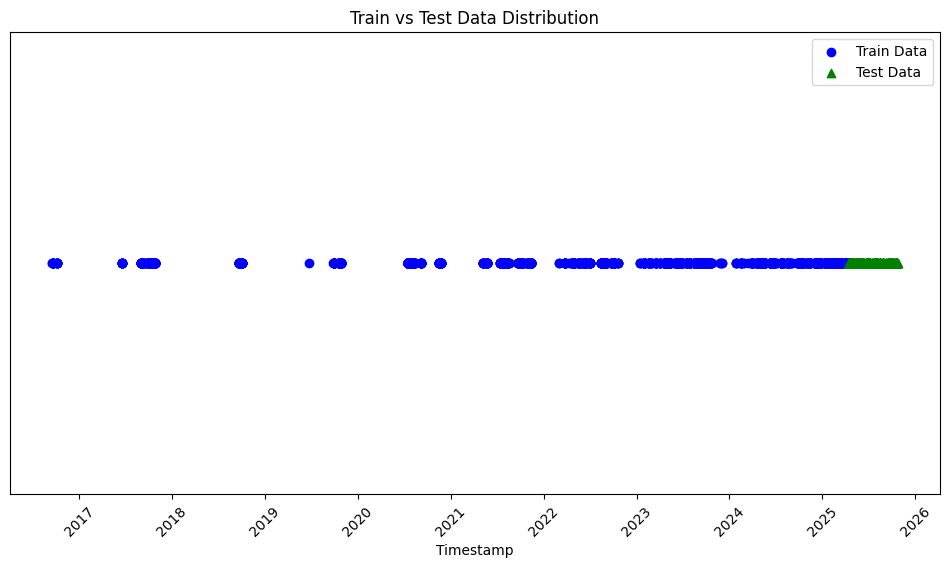

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
all_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360_fixed_512/'
df = pd.read_csv(all_csv)
df['date'] = pd.to_datetime(df['datetime'])
train_df = df[(df['date'] < '2023-08-20')]  #2025-04-15
test_df = df[(df['date'] >= '2023-08-20')]
print(f'training set {len(train_df)} testing set {len(test_df)}')

# Translated comment
plt.figure(figsize=(12, 6))

plt.scatter(train_df['date'], [1] * len(train_df), color='blue', label='Train Data', marker='o')

# Translated comment
plt.scatter(test_df['date'], [1] * len(test_df), color='green', label='Test Data', marker='^')

# Translated comment
plt.title('Train vs Test Data Distribution')
plt.xlabel('Timestamp')
plt.yticks([])  # Translated comment
plt.legend()

# Translated comment
plt.xticks(rotation=45)

# Translated comment
plt.show()


In [2]:
# Translated comment
import os
import pandas as pd
import numpy as np
import tifffile
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math
import imagecodecs  # keep if you need it

base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_90360_32_middlesplit"
train_csv_path = os.path.join(base_dir, "train.csv")
test_csv_path = os.path.join(base_dir, "test.csv")

origin_train_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_CDSE0_gee90360_original_middlesplit/train.csv"
origin_test_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_CDSE0_gee90360_original_middlesplit/test.csv"

os.makedirs(base_dir, exist_ok=True)

image_size = 32
band_index = 11  # Translated comment
zero_ratio_thresh = 0.20

N_POS = 8
N_NEG = 8

def to_chw(data):
    if data.ndim == 2:
        return data[None, :, :]
    if data.ndim != 3:
        return None
    # Translated comment
    if data.shape[0] in (12, 13):        # CHW
        return data
    if data.shape[-1] in (12, 13):       # HWC
        return data.transpose(2, 0, 1)
    # Translated comment
    if data.shape[0] <= 20 and data.shape[0] < data.shape[-1]:
        return data
    return data.transpose(2, 0, 1)

def get_crop(width=512, height=512, center_size=20, crop_width=128):
    """
    Return (x, y): x = left (col), y = top (row)
    """
    center_x = width // 2
    center_y = height // 2
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    left_min = max(0, center_right - crop_width)
    left_max = min(center_left, width - crop_width)
    top_min = max(0, center_bottom - crop_width)
    top_max = min(center_top, height - crop_width)

    x = random.randint(left_min, left_max)
    y = random.randint(top_min, top_max)
    return x, y

def is_center_contained(crop_xy, image_size=32, width=512, height=512, center_size=10):
    """
    crop_xy: (x, y)
    """
    center_x = width // 2
    center_y = height // 2

    cx1 = center_x - center_size // 2
    cy1 = center_y - center_size // 2
    cx2 = center_x + center_size // 2
    cy2 = center_y + center_size // 2

    x, y = crop_xy
    x1, y1 = x, y
    x2, y2 = x + image_size, y + image_size

    return (x1 <= cx1 and y1 <= cy1 and x2 >= cx2 and y2 >= cy2)

class ThreadSafeCounter:
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def band12_zero_too_much(arr_chw):
    total = arr_chw[band_index].size
    if total == 0:
        return True
    zero_count = np.sum(arr_chw[band_index] == 0)
    return (zero_count / total) >= zero_ratio_thresh

def crop_chw(arr_chw, crop_xy, size):
    """
    arr_chw: (C,H,W)
    crop_xy: (x,y) where x=col, y=row
    """
    x, y = crop_xy
    return arr_chw[:, y:y+size, x:x+size]

def crop_hw(arr_hw, crop_xy, size):
    x, y = crop_xy
    return arr_hw[y:y+size, x:x+size]

def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = to_chw(tifffile.imread(row["s2_path_std"]))
    t1_data = to_chw(tifffile.imread(row["s2_90_path_std"]))
    t2_data = to_chw(tifffile.imread(row["s2_360_path_std"]))
    mask = tifffile.imread(row["resized_512x512_path"])  # (H,W)

    if t_data is None or t1_data is None or t2_data is None or mask is None:
        return []

    data = []

    # Translated comment
    crop_list = [get_crop(crop_width=image_size) for _ in range(N_POS)]
    for crop_xy in crop_list:
        nt_data = crop_chw(t_data, crop_xy, image_size)
        nt1_data = crop_chw(t1_data, crop_xy, image_size)
        nt2_data = crop_chw(t2_data, crop_xy, image_size)
        n_mask  = crop_hw(mask, crop_xy, image_size)

        # Translated comment
        if nt_data.shape[-2:] != (image_size, image_size) or n_mask.shape != (image_size, image_size):
            continue

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")
        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_pre_path": nt1_path,
            "s2_pre_pre_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })
        plume_cnt.increment()

    # Translated comment
    crop_list = [(random.randint(0, 512 - image_size), random.randint(0, 512 - image_size)) for _ in range(N_NEG)]
    for crop_xy in crop_list:
        nt_data = crop_chw(t_data, crop_xy, image_size)
        nt1_data = crop_chw(t1_data, crop_xy, image_size)
        nt2_data = crop_chw(t2_data, crop_xy, image_size)
        n_mask  = crop_hw(mask, crop_xy, image_size)

        if nt_data.shape[-2:] != (image_size, image_size) or n_mask.shape != (image_size, image_size):
            continue

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")

        label = is_center_contained(crop_xy, image_size=image_size)
        if not label:
            n_mask = np.zeros((image_size, image_size), dtype=mask.dtype)
        else:
            plume_cnt.increment()

        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_pre_path": nt1_path,
            "s2_pre_pre_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 0 if not label else 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })

    print(f"processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}")
    return data

def run_split(csv_path, out_csv_path, output_cnt, plume_cnt):
    org_df = pd.read_csv(csv_path)
    data_all = []

    batch_size = 32
    total_rows = len(org_df)
    num_batches = math.ceil(total_rows / batch_size)

    for batch_num in range(num_batches):
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, total_rows)
        batch_df = org_df.iloc[start_idx:end_idx]

        futures = []
        with ThreadPoolExecutor(max_workers=16) as executor:
            for index, row in batch_df.iterrows():
                futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))
            for future in futures:
                data_all.extend(future.result())

    out_df = pd.DataFrame(data_all)
    out_df.to_csv(out_csv_path, index=False)
    print(f"wrote {out_csv_path}, size={len(out_df)}")
    return out_df

output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()

train_df = run_split(origin_train_csv, train_csv_path, output_cnt, plume_cnt)
test_df = run_split(origin_test_csv, test_csv_path, output_cnt, plume_cnt)

print(f"total count: {len(train_df) + len(test_df)}")
print(f"train label sum: {train_df['label'].sum()} / {len(train_df)}")
print(f"test label sum: {test_df['label'].sum()} / {len(test_df)}")


ValueError: the first parameter must be a file name or seekable binary file object, not <class 'float'>

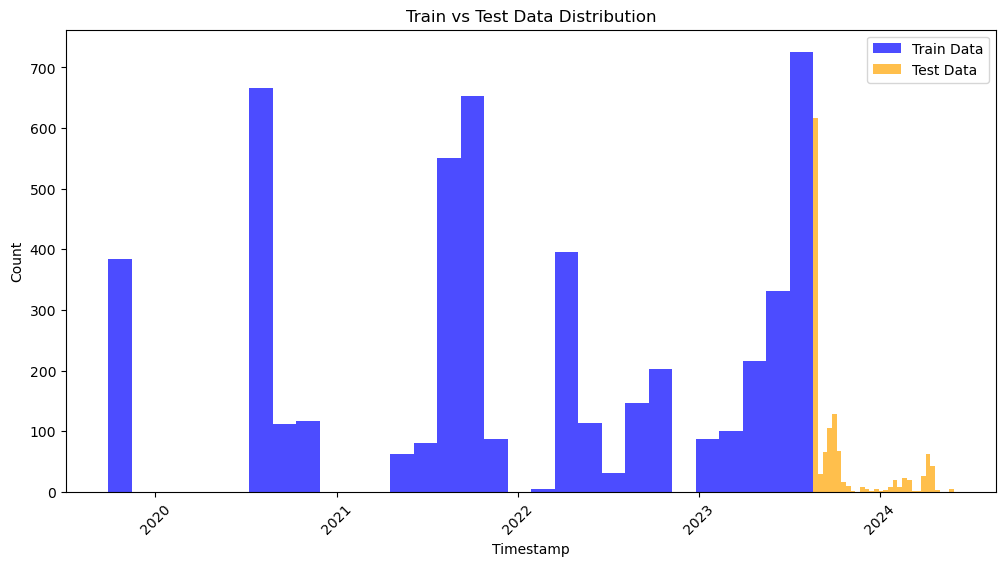

In [3]:
train_data = df[(df['date'] < '2023-08-20')]['date']
test_data = df[(df['date'] >= '2023-08-20')]['date']

plt.figure(figsize=(12, 6))

# Translated comment
plt.hist(train_data, bins=30, alpha=0.7, label='Train Data', color='blue')
plt.hist(test_data, bins=30, alpha=0.7, label='Test Data', color='orange')

# Translated comment
plt.title('Train vs Test Data Distribution')
plt.xlabel('Timestamp')
plt.ylabel('Count')
plt.legend()

# Translated comment
plt.xticks(rotation=45)

# Translated comment
plt.show()

In [4]:
import pandas as pd
train_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_test_data_classification_location/train.csv'
test_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_test_data_classification_location/test.csv'
train_df = pd.read_csv(train_csv_path)
train_plume_df = train_df[train_df['label'] == 1]
print(f'train set size {len(train_plume_df)}/{len(train_df)}')

test_df = pd.read_csv(test_csv_path)
test_plume_df = test_df[test_df['label'] == 1]
print(f'test set size {len(test_plume_df)}/{len(test_df)}')

train set size 47853/96106
test set size 10671/20805


    latitude_center  longitude_center  cluster
0         32.025415       -102.472451        0
1         31.409842         47.819403        1
2         30.940793          5.351986        2
3        -34.896643        -69.699012        3
4         38.289140       -108.310040        4
5         35.724409        108.985170        5
6         35.726835       -119.517861        6
7         40.013858        -80.591491        7
8         39.191839         60.554444        8
9         30.830023         31.822978        9
10       -25.597949        149.236048       10
11        30.957061         76.934142       11
12        47.326754       -118.850943       12
13         9.753137        -73.442117       13
14        40.191390       -104.563848       14
15        41.337481        -88.323371       15
16        33.592756        -85.509143       16
17       -22.613021        -47.420267       17
18       -25.458609         28.110487       18
19        29.313593        -92.717572       19


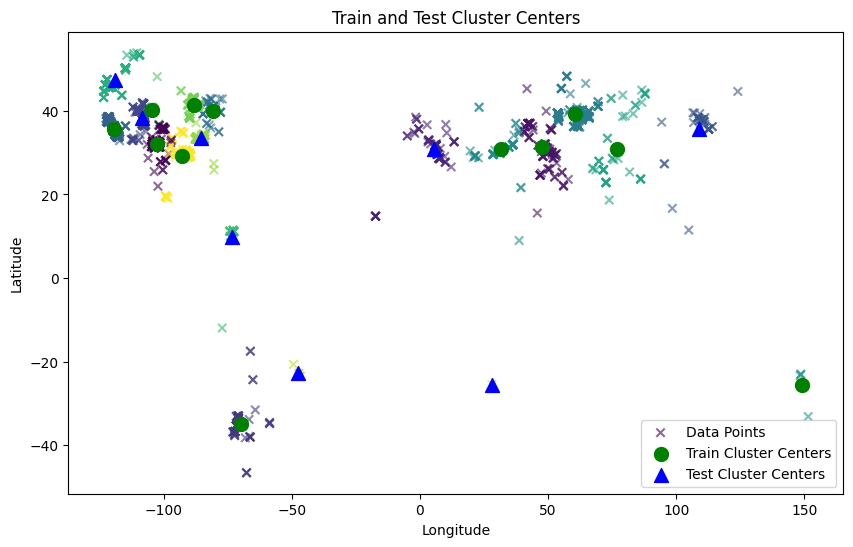

In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

all_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction/all.csv'
df = pd.read_csv(all_csv)

n_clusters = 20

kmeans = KMeans(n_clusters=n_clusters, random_state=0)
df['cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

# Translated comment
cluster_centers = kmeans.cluster_centers_

# Translated comment
centers_df = pd.DataFrame(cluster_centers, columns=['latitude_center', 'longitude_center'])
centers_df['cluster'] = centers_df.index 
# Translated comment
print(centers_df)

train_clusters, test_clusters = train_test_split(
    df['cluster'].unique(), test_size=0.4, random_state=0
)

# Translated comment
train_df = df[df['cluster'].isin(train_clusters)].reset_index(drop=True)
test_df = df[df['cluster'].isin(test_clusters)].reset_index(drop=True)

train_centers = centers_df[centers_df['cluster'].isin(train_clusters)]
test_centers = centers_df[centers_df['cluster'].isin(test_clusters)]

plt.figure(figsize=(10, 6))
plt.scatter(df['longitude'], df['latitude'], c=df['cluster'], cmap='viridis', marker='x', alpha=0.6, label='Data Points')
# Translated comment
plt.scatter(train_centers['longitude_center'], train_centers['latitude_center'], 
            c='green', marker='o', s=100, label='Train Cluster Centers')

# Translated comment
plt.scatter(test_centers['longitude_center'], test_centers['latitude_center'], 
            c='blue', marker='^', s=100, label='Test Cluster Centers')

# Translated comment
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Train and Test Cluster Centers')
plt.legend()

# Translated comment
plt.show()




# Translated comment
print("sample:", len(train_df))
print("sample:", len(test_df))

train_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_location/train.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_location/test.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')

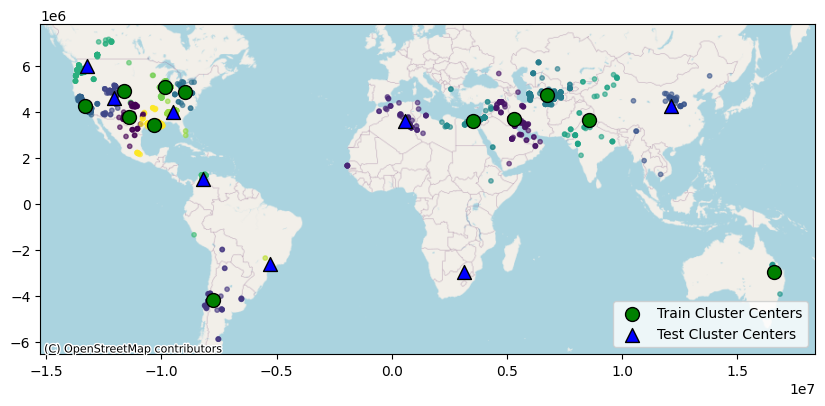

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
# Translated comment
gdf = gpd.GeoDataFrame(df, 
                       geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
                       crs="EPSG:4326")

train_centers_gdf = gpd.GeoDataFrame(train_centers, 
                                     geometry=gpd.points_from_xy(train_centers['longitude_center'], 
                                                                 train_centers['latitude_center']),
                                     crs="EPSG:4326")

test_centers_gdf = gpd.GeoDataFrame(test_centers, 
                                    geometry=gpd.points_from_xy(test_centers['longitude_center'], 
                                                                test_centers['latitude_center']),
                                    crs="EPSG:4326")

# Translated comment
gdf = gdf.to_crs(epsg=3857)
train_centers_gdf = train_centers_gdf.to_crs(epsg=3857)
test_centers_gdf = test_centers_gdf.to_crs(epsg=3857)

# Translated comment
fig, ax = plt.subplots(figsize=(10, 6))

# Translated comment
gdf.plot(ax=ax, column='cluster', cmap='viridis', markersize=10, alpha=0.6, legend=False)

# Translated comment
train_centers_gdf.plot(ax=ax, color='green', marker='o', markersize=100, edgecolor='black', label='Train Cluster Centers')

# Translated comment
test_centers_gdf.plot(ax=ax, color='blue', marker='^', markersize=100, edgecolor='black', label='Test Cluster Centers')

# Translated comment
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Translated comment
# plt.xlabel('X (meters, Web Mercator)', fontsize = 14)
# plt.ylabel('Y (meters, Web Mercator)', fontsize = 14)
# plt.title('Train and Test Cluster Centers with Data Points')
plt.legend()

# Translated comment
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import rasterio
import tifffile
import json
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math

base_dir = '/home/hongxuan/methane/carbonmapper_3_90_365_l2a_test_data_classification_temporal_16'
train_csv_path = '/home/hongxuan/methane/carbonmapper_3_90_365_l2a_test_data_classification_temporal_16/train.csv'
origin_train_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_temporal/train.csv'
test_csv_path = '/home/hongxuan/methane/carbonmapper_3_90_365_l2a_test_data_classification_temporal_16/test.csv'
origin_test_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_temporal/test.csv'

os.makedirs(base_dir, exist_ok=True)

def get_crop(width = 512, height = 512, center_size = 10, crop_width = 128):
    
    center_x = width // 2
    center_y = height // 2

    # Translated comment
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    # Translated comment
    # Translated comment
    left_min = max(0, center_right - crop_width)  # Translated comment
    left_max = min(center_left, width - crop_width)  # Translated comment

    top_min = max(0, center_bottom - crop_width)  # Translated comment
    top_max = min(center_top, height - crop_width)  # Translated comment

    # Translated comment
    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)

    return left, top


data = []

image_size = 16

cnt = 0
plume_cnt = 0
org_train_df = pd.read_csv(origin_train_csv)
# crop_list = [(0, 0), (0, 512 - 96), (512 - 96, 512 - 96), (512 - 96, 0), (256 - 96, 256 - 96), (256 - 96, 256), (256, 256), (256, 256 - 96)]

class ThreadSafeCounter():
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def is_center_contained(crop, image_size = 128, width = 512, height = 512):

    center_x = width // 2
    center_y = height // 2
    center_size = 10

    # Translated comment
    center_x1 = center_x - center_size // 2
    center_y1 = center_y - center_size // 2
    center_x2 = center_x + center_size // 2
    center_y2= center_y + center_size // 2
    
    crop_x1 = crop[0]
    crop_y1 = crop[1]
    crop_x2 = crop[0] + image_size
    crop_y2 = crop[1] + image_size
    
    # Translated comment
    if (crop_x1 <= center_x1 and crop_y1 <= center_y1 and
        crop_x2 >= center_x2 and crop_y2 >= center_y2):
        return True
    else:
        return False

def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = tifffile.imread(row['s2_path'])
    t_data = t_data.transpose(2, 0, 1)
    # total_elements = t_data[12].size
    # zero_count = np.sum(t_data[12] == 0)
    # if zero_count >= (total_elements // 5):
    #     continue
    t1_data = tifffile.imread(row['s2_pre_path'])
    t1_data = t1_data.transpose(2, 0, 1)
    t2_data = tifffile.imread(row['s2_pre_pre_path'])
    t2_data = t2_data.transpose(2, 0, 1)
    mask = tifffile.imread(row['plume_mask_path'])
    data = []
    crop_list = []
    for i in range(8):
        crop_list.append(get_crop(crop_width = image_size))
    
    for crop in crop_list:
        nt_data = t_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        total_elements = nt_data[11].size
        zero_count = np.sum(nt_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt1_data[11].size
        zero_count = np.sum(nt1_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt2_data[11].size
        zero_count = np.sum(nt2_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)
        nt_path = os.path.join(base_dir, str(cnt), "s2.tif")
        tifffile.imwrite(nt_path, nt_data)
        nt1_path = os.path.join(base_dir, str(cnt), "s2_pre.tif")
        tifffile.imwrite(nt1_path, nt1_data)
        nt2_path = os.path.join(base_dir, str(cnt), "s2_pre_pre.tif")
        tifffile.imwrite(nt2_path, nt2_data)
        n_mask_path = os.path.join(base_dir, str(cnt), "plume.tif")
        tifffile.imwrite(n_mask_path, n_mask)
        # , "s2_post_path": nt2_path
        data.append({"id": cnt, "s2_path": nt_path, "s2_pre_path": nt1_path, "s2_pre_pre_path": nt2_path, "plume_mask_path": n_mask_path, "label": 1, "emission_auto": row['emission_auto'], "emission_uncertainty_auto": row['emission_uncertainty_auto'], 'latitude': row['latitude'], 'longitude': row['longitude']})
        plume_cnt.increment()
    crop_list = []
    for i in range(8):
        crop_list.append((random.randint(0, 512 - image_size), random.randint(0, 512 - image_size)))

    # plt.imshow(t_data[12])
    # plt.colorbar(label='MBMP')
    # plt.title('Band 12')
    # plt.show()

    for crop in crop_list:
        nt_data = t_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        total_elements = nt_data[11].size
        zero_count = np.sum(nt_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt1_data[11].size
        zero_count = np.sum(nt1_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt2_data[11].size
        zero_count = np.sum(nt2_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)
        nt_path = os.path.join(base_dir, str(cnt), "s2.tif")
        tifffile.imwrite(nt_path, nt_data)
        nt1_path = os.path.join(base_dir, str(cnt), "s2_pre.tif")
        tifffile.imwrite(nt1_path, nt1_data)
        nt2_path = os.path.join(base_dir, str(cnt), "s2_pre_pre.tif")
        tifffile.imwrite(nt2_path, nt2_data)

        label = is_center_contained(crop, image_size = image_size)
        if not label:
            n_mask = np.zeros((image_size, image_size))
        else:
            plume_cnt.increment()

        n_mask_path = os.path.join(base_dir, str(cnt), "plume.tif")
        tifffile.imwrite(n_mask_path, n_mask)
        
        # , "s2_post_path": nt2_path
        data.append({"id": cnt, "s2_path": nt_path, "s2_pre_path": nt1_path, "s2_pre_pre_path": nt2_path, "plume_mask_path": n_mask_path, "label": 0 if not label else 1, "emission_auto": 0 if not label else row['emission_auto'], "emission_uncertainty_auto": 0 if not label else row['emission_uncertainty_auto'], 'latitude': row['latitude'], 'longitude': row['longitude']})
    print(f'processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}')
    return data

data_train = []
futures = []
output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()
# with ThreadPoolExecutor(max_workers=16) as executor:
#     for index, row in org_train_df.iterrows():
#         futures.append(executor.submit(process_row, row, index, len(org_train_df), output_cnt, plume_cnt))

#     for future in futures:
#         data_train.extend(future.result())
batch_size = 32
total_rows = len(org_train_df)
num_batches = math.ceil(total_rows / batch_size)

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min((batch_num + 1) * batch_size, total_rows)

    batch_df = org_train_df.iloc[start_idx:end_idx]
    futures = []

    with ThreadPoolExecutor(max_workers=16) as executor:
        for index, row in batch_df.iterrows():
            futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))

        for future in futures:
            data_train.extend(future.result())
    
train_df = pd.DataFrame(data_train)
train_df.to_csv(train_csv_path, index=False)
print(f'training set count: {len(data_train)}')


data_test = []
futures = []
org_test_df = pd.read_csv(origin_test_csv)
# with ThreadPoolExecutor(max_workers=16) as executor:
#     for index, row in org_test_df.iterrows():
#         futures.append(executor.submit(process_row, row, index, len(org_test_df), output_cnt, plume_cnt))

#     for future in futures:
#         data_test.extend(future.result())

batch_size = 32
total_rows = len(org_test_df)
num_batches = math.ceil(total_rows / batch_size)

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min((batch_num + 1) * batch_size, total_rows)

    batch_df = org_test_df.iloc[start_idx:end_idx]
    futures = []

    with ThreadPoolExecutor(max_workers=16) as executor:
        for index, row in batch_df.iterrows():
            futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))

        for future in futures:
            data_test.extend(future.result())


test_df = pd.DataFrame(data_test)
test_df.to_csv(test_csv_path, index=False)
print(f'total count: {len(data_train) + len(data_test)}')

column_sum = train_df['label'].sum()
print(f"label: {column_sum} total {len(train_df)}")

column_sum = test_df['label'].sum()
print(f"label: {column_sum} total {len(test_df)}")

processed 1 / 5067 plume_cnt 107 / 139
processed 6 / 5067 plume_cnt 117 / 157
processed 0 / 5067 plume_cnt 128 / 190
processed 3 / 5067 plume_cnt 128 / 229
processed 5 / 5067 plume_cnt 128 / 230
processed 10 / 5067 plume_cnt 128 / 232
processed 2 / 5067 plume_cnt 128 / 234
processed 15 / 5067 plume_cnt 128 / 237
processed 12 / 5067 plume_cnt 128 / 245
processed 8 / 5067 plume_cnt 128 / 247
processed 9 / 5067 plume_cnt 128 / 247
processed 7 / 5067 plume_cnt 128 / 248
processed 4 / 5067 plume_cnt 128 / 250
processed 14 / 5067 plume_cnt 128 / 252
processed 11 / 5067 plume_cnt 128 / 252
processed 13 / 5067 plume_cnt 128 / 252
processed 17 / 5067 plume_cnt 144 / 282
processed 16 / 5067 plume_cnt 144 / 282
processed 23 / 5067 plume_cnt 253 / 452
processed 20 / 5067 plume_cnt 256 / 469
processed 19 / 5067 plume_cnt 256 / 472
processed 22 / 5067 plume_cnt 256 / 472
processed 18 / 5067 plume_cnt 256 / 480
processed 21 / 5067 plume_cnt 256 / 481
processed 31 / 5067 plume_cnt 256 / 482
processed 

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import rasterio
import tifffile
import json
import random
import threading
from concurrent.futures import ThreadPoolExecutor

base_dir = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian'
train_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/train.csv'
origin_train_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_test_extraction_permian_temporal/train.csv'
test_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/test.csv'
origin_test_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_test_extraction_permian_temporal/test.csv'

os.makedirs(base_dir, exist_ok=True)

def get_crop(width = 512, height = 512, center_size = 20, crop_width = 128, crop_height = 128):
    
    center_x = width // 2
    center_y = height // 2

    # Translated comment
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    # Translated comment
    # Translated comment
    left_min = max(0, center_right - crop_width)  # Translated comment
    left_max = min(center_left, width - crop_width)  # Translated comment

    top_min = max(0, center_bottom - crop_height)  # Translated comment
    top_max = min(center_top, height - crop_height)  # Translated comment

    # Translated comment
    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)

    return left, top


data = []

image_size = 128

cnt = 0
plume_cnt = 0
org_train_df = pd.read_csv(origin_train_csv)
# crop_list = [(0, 0), (0, 512 - 96), (512 - 96, 512 - 96), (512 - 96, 0), (256 - 96, 256 - 96), (256 - 96, 256), (256, 256), (256, 256 - 96)]

class ThreadSafeCounter():
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter


def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = tifffile.imread(row['s2_path'])
    t_data = t_data.transpose(2, 0, 1)
    # total_elements = t_data[12].size
    # zero_count = np.sum(t_data[12] == 0)
    # if zero_count >= (total_elements // 5):
    #     continue
    t1_data = tifffile.imread(row['s2_pre_path'])
    t1_data = t1_data.transpose(2, 0, 1)
    t2_data = tifffile.imread(row['s2_pre_pre_path'])
    t2_data = t2_data.transpose(2, 0, 1)
    mask = tifffile.imread(row['plume_mask_path'])
    data = []
    crop_list = []
    for i in range(8):
        crop_list.append(get_crop())
    for i in range(12):
        crop_list.append((random.randint(0, 374), random.randint(0, 374)))

    # plt.imshow(t_data[12])
    # plt.colorbar(label='MBMP')
    # plt.title('Band 12')
    # plt.show()

    for crop in crop_list:
        nt_data = t_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        total_elements = nt_data[12].size
        zero_count = np.sum(nt_data[12] == 0)
        # print(f'{zero_count} / {total_elements}')
        if zero_count >= (total_elements // 2):
            continue
        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)
        nt_path = os.path.join(base_dir, str(cnt), "s2.tif")
        tifffile.imwrite(nt_path, nt_data)
        nt1_path = os.path.join(base_dir, str(cnt), "s2_-5.tif")
        tifffile.imwrite(nt1_path, nt1_data)
        nt2_path = os.path.join(base_dir, str(cnt), "s2_pre_pre.tif")
        tifffile.imwrite(nt2_path, nt2_data)
        n_mask_path = os.path.join(base_dir, str(cnt), "plume.tif")
        tifffile.imwrite(n_mask_path, n_mask)
        mask_sum = np.sum(n_mask)
        # , "s2_post_path": nt2_path
        data.append({"id": cnt, "s2_path": nt_path, "s2_pre_path": nt1_path, "s2_pre_pre_path": nt2_path, "plume_mask_path": n_mask_path, "label": 0 if mask_sum == 0 else 1, "emission_auto": 0 if mask_sum == 0 else row['emission_auto'], "emission_uncertainty_auto": 0 if mask_sum == 0 else row['emission_uncertainty_auto'], 'latitude': row['latitude'], 'longitude': row['longitude']})
        if mask_sum != 0:
            plume_cnt.increment()
    print(f'processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}')
    return data

data_train = []
futures = []
output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()
with ThreadPoolExecutor(max_workers=32) as executor:
    for index, row in org_train_df.iterrows():
        futures.append(executor.submit(process_row, row, index, len(org_train_df), output_cnt, plume_cnt))

    for future in futures:
        data_train.extend(future.result())
    
train_df = pd.DataFrame(data_train)
train_df.to_csv(train_csv_path, index=False)
print(f'training set count: {len(data_train)}')


data_test = []
futures = []
org_test_df = pd.read_csv(origin_test_csv)
with ThreadPoolExecutor(max_workers=32) as executor:
    for index, row in org_test_df.iterrows():
        futures.append(executor.submit(process_row, row, index, len(org_test_df), output_cnt, plume_cnt))

    for future in futures:
        data_test.extend(future.result())


test_df = pd.DataFrame(data_test)
test_df.to_csv(test_csv_path, index=False)
print(f'total count: {len(data_train) + len(data_test)}')

column_sum = train_df['label'].sum()
print(f"label: {column_sum} total {len(train_df)}")

column_sum = test_df['label'].sum()
print(f"label: {column_sum} total {len(test_df)}")

processed 27 / 2577 plume_cnt 301 / 588
processed 14 / 2577 plume_cnt 301 / 596
processed 13 / 2577 plume_cnt 302 / 603
processed 12 / 2577 plume_cnt 302 / 612
processed 26 / 2577 plume_cnt 305 / 615
processed 25 / 2577 plume_cnt 305 / 617
processed 11 / 2577 plume_cnt 306 / 623
processed 7 / 2577 plume_cnt 307 / 628
processed 23 / 2577 plume_cnt 307 / 628
processed 15 / 2577 plume_cnt 307 / 628
processed 28 / 2577 plume_cnt 308 / 640
processed 19 / 2577 plume_cnt 309 / 640
processed 18 / 2577 plume_cnt 309 / 641
processed 16 / 2577 plume_cnt 309 / 641
processed 21 / 2577 plume_cnt 309 / 641
processed 3 / 2577 plume_cnt 309 / 641
processed 9 / 2577 plume_cnt 309 / 642
processed 5 / 2577 plume_cnt 311 / 645
processed 4 / 2577 plume_cnt 311 / 645
processed 6 / 2577 plume_cnt 312 / 646
processed 29 / 2577 plume_cnt 312 / 647
processed 20 / 2577 plume_cnt 312 / 648
processed 8 / 2577 plume_cnt 312 / 648
processed 17 / 2577 plume_cnt 312 / 648
processed 31 / 2577 plume_cnt 312 / 648
process

In [1]:
import pandas as pd
train_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/train.csv'
test_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/test.csv'

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)


column_sum = train_df['label'].sum()
print(f"label: {column_sum} total {len(train_df)}")

column_sum = test_df['label'].sum()
print(f"label: {column_sum} total {len(test_df)}")

label: 27210 total 55596
label: 5579 total 11247


In [ ]:
import os
import pandas as pd
import numpy as np
import tifffile
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math
import imagecodecs

base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_90360_32_filtered"
train_csv_path = os.path.join(base_dir, "train.csv")
test_csv_path = os.path.join(base_dir, "test.csv")

origin_train_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_filtered/train.csv"
origin_test_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_filtered/test.csv"

os.makedirs(base_dir, exist_ok=True)

image_size = 32
band_index = 11  # Translated comment
zero_ratio_thresh = 0.20

def to_chw(data):
    if data.ndim == 2:
        return data[None, :, :]
    if data.ndim != 3:
        return None
    # Translated comment
    if data.shape[0] <= 20 and data.shape[0] < data.shape[-1]:
        return data  # Translated comment
    return data.transpose(2, 0, 1)  # HWC -> CHW

def get_crop(width=512, height=512, center_size=20, crop_width=128):
    center_x = width // 2
    center_y = height // 2
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    left_min = max(0, center_right - crop_width)
    left_max = min(center_left, width - crop_width)
    top_min = max(0, center_bottom - crop_width)
    top_max = min(center_top, height - crop_width)

    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)
    return left, top

def is_center_contained(crop, image_size=32, width=512, height=512):
    center_x = width // 2
    center_y = height // 2
    center_size = 10

    center_x1 = center_x - center_size // 2
    center_y1 = center_y - center_size // 2
    center_x2 = center_x + center_size // 2
    center_y2 = center_y + center_size // 2

    crop_x1 = crop[0]
    crop_y1 = crop[1]
    crop_x2 = crop[0] + image_size
    crop_y2 = crop[1] + image_size

    return (crop_x1 <= center_x1 and crop_y1 <= center_y1 and
            crop_x2 >= center_x2 and crop_y2 >= center_y2)

class ThreadSafeCounter:
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def band12_zero_too_much(arr):
    total = arr[band_index].size
    zero_count = np.sum(arr[band_index] == 0)
    return zero_count / total >= zero_ratio_thresh

def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = to_chw(tifffile.imread(row["s2_path"]))
    t1_data = to_chw(tifffile.imread(row["s2_90_path"]))
    t2_data = to_chw(tifffile.imread(row["s2_360_path"]))
    mask = tifffile.imread(row["resized_512x512_path"])

    if t_data is None or t1_data is None or t2_data is None:
        return []

    data = []

    # Translated comment
    crop_list = [get_crop(crop_width=image_size) for _ in range(8)]
    for crop in crop_list:
        nt_data = t_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")
        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_90_path": nt1_path,
            "s2_360_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })
        plume_cnt.increment()

    # Translated comment
    crop_list = [(random.randint(0, 512 - image_size), random.randint(0, 512 - image_size)) for _ in range(8)]
    for crop in crop_list:
        nt_data = t_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")

        label = is_center_contained(crop, image_size=image_size)
        if not label:
            n_mask = np.zeros((image_size, image_size), dtype=mask.dtype)
        else:
            plume_cnt.increment()

        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_90_path": nt1_path,
            "s2_360_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 0 if not label else 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })

    print(f"processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}")
    return data

def run_split(csv_path, out_csv_path, output_cnt, plume_cnt):
    org_df = pd.read_csv(csv_path)
    data_all = []

    batch_size = 32
    total_rows = len(org_df)
    num_batches = math.ceil(total_rows / batch_size)

    for batch_num in range(num_batches):
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, total_rows)
        batch_df = org_df.iloc[start_idx:end_idx]

        futures = []
        with ThreadPoolExecutor(max_workers=16) as executor:
            for index, row in batch_df.iterrows():
                futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))
            for future in futures:
                data_all.extend(future.result())

    out_df = pd.DataFrame(data_all)
    out_df.to_csv(out_csv_path, index=False)
    print(f"wrote {out_csv_path}, size={len(out_df)}")
    return out_df

output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()

train_df = run_split(origin_train_csv, train_csv_path, output_cnt, plume_cnt)
test_df = run_split(origin_test_csv, test_csv_path, output_cnt, plume_cnt)

print(f"total count: {len(train_df) + len(test_df)}")
print(f"train label sum: {train_df['label'].sum()} / {len(train_df)}")
print(f"test label sum: {test_df['label'].sum()} / {len(test_df)}")

processed 1 / 3457 plume_cnt 128 / 253
processed 6 / 3457 plume_cnt 128 / 253
processed 7 / 3457 plume_cnt 128 / 253
processed 10 / 3457 plume_cnt 128 / 254
processed 8 / 3457 plume_cnt 128 / 254
processed 14 / 3457 plume_cnt 128 / 254
processed 13 / 3457 plume_cnt 128 / 254
processed 0 / 3457 plume_cnt 128 / 255
processed 15 / 3457 plume_cnt 128 / 255
processed 5 / 3457 plume_cnt 128 / 255
processed 12 / 3457 plume_cnt 128 / 256
processed 2 / 3457 plume_cnt 128 / 256
processed 9 / 3457 plume_cnt 128 / 256
processed 20 / 3457 plume_cnt 128 / 256
processed 4 / 3457 plume_cnt 128 / 256
processed 3 / 3457 plume_cnt 128 / 263
processed 25 / 3457 plume_cnt 128 / 263
processed 11 / 3457 plume_cnt 128 / 263
processed 18 / 3457 plume_cnt 240 / 461
processed 27 / 3457 plume_cnt 240 / 472
processed 17 / 3457 plume_cnt 240 / 476
processed 16 / 3457 plume_cnt 240 / 476
processed 21 / 3457 plume_cnt 240 / 476
processed 26 / 3457 plume_cnt 240 / 479
processed 30 / 3457 plume_cnt 240 / 479
processed 

In [ ]:
import numpy as np
import tifffile

# Translated comment
num_channels = 13

channel_sums = np.zeros(num_channels, dtype=np.float64)
total_pixels = 0

all_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_test_extraction/all.csv'
df = pd.read_csv(all_csv)

# Translated comment
for index, row in df.iterrows():

    data = tifffile.imread(row['s2_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
 print(f": file {row['s2_path']} NaN Inf . 0.")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_sums[channel] += channel_data.sum()

    total_pixels += data.shape[0] * data.shape[1]

    data = tifffile.imread(row['s2_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
 print(f": file {row['s2_pre_path']} NaN Inf . 0.")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_sums[channel] += channel_data.sum()

    # Translated comment
    total_pixels += data.shape[0] * data.shape[1]

    data = tifffile.imread(row['s2_pre_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
 print(f": file {row['s2_pre_pre_path']} NaN Inf . 0.")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_sums[channel] += channel_data.sum()

    # Translated comment
    total_pixels += data.shape[0] * data.shape[1]

    # if index > 100:
    #     break


channel_means = channel_sums / total_pixels

# Translated comment
channel_squared_sums = np.zeros(num_channels, dtype=np.float64)


for index, row in df.iterrows():

    data = tifffile.imread(row['s2_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
 print(f": file {row['s2_path']} NaN Inf . 0.")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_squared_sums[channel] += ((channel_data - channel_means[channel]) ** 2).sum()

    data = tifffile.imread(row['s2_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
 print(f": file {row['s2_pre_path']} NaN Inf . 0.")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_squared_sums[channel] += ((channel_data - channel_means[channel]) ** 2).sum()

    data = tifffile.imread(row['s2_pre_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
 print(f": file {row['s2_pre_pre_path']} NaN Inf . 0.")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_squared_sums[channel] += ((channel_data - channel_means[channel]) ** 2).sum()

    # if index > 100:
    #     break

channel_stddevs = np.sqrt(channel_squared_sums / total_pixels)

print("channels: ", channel_means)
print("channels: ", channel_stddevs)